5.596780058752004


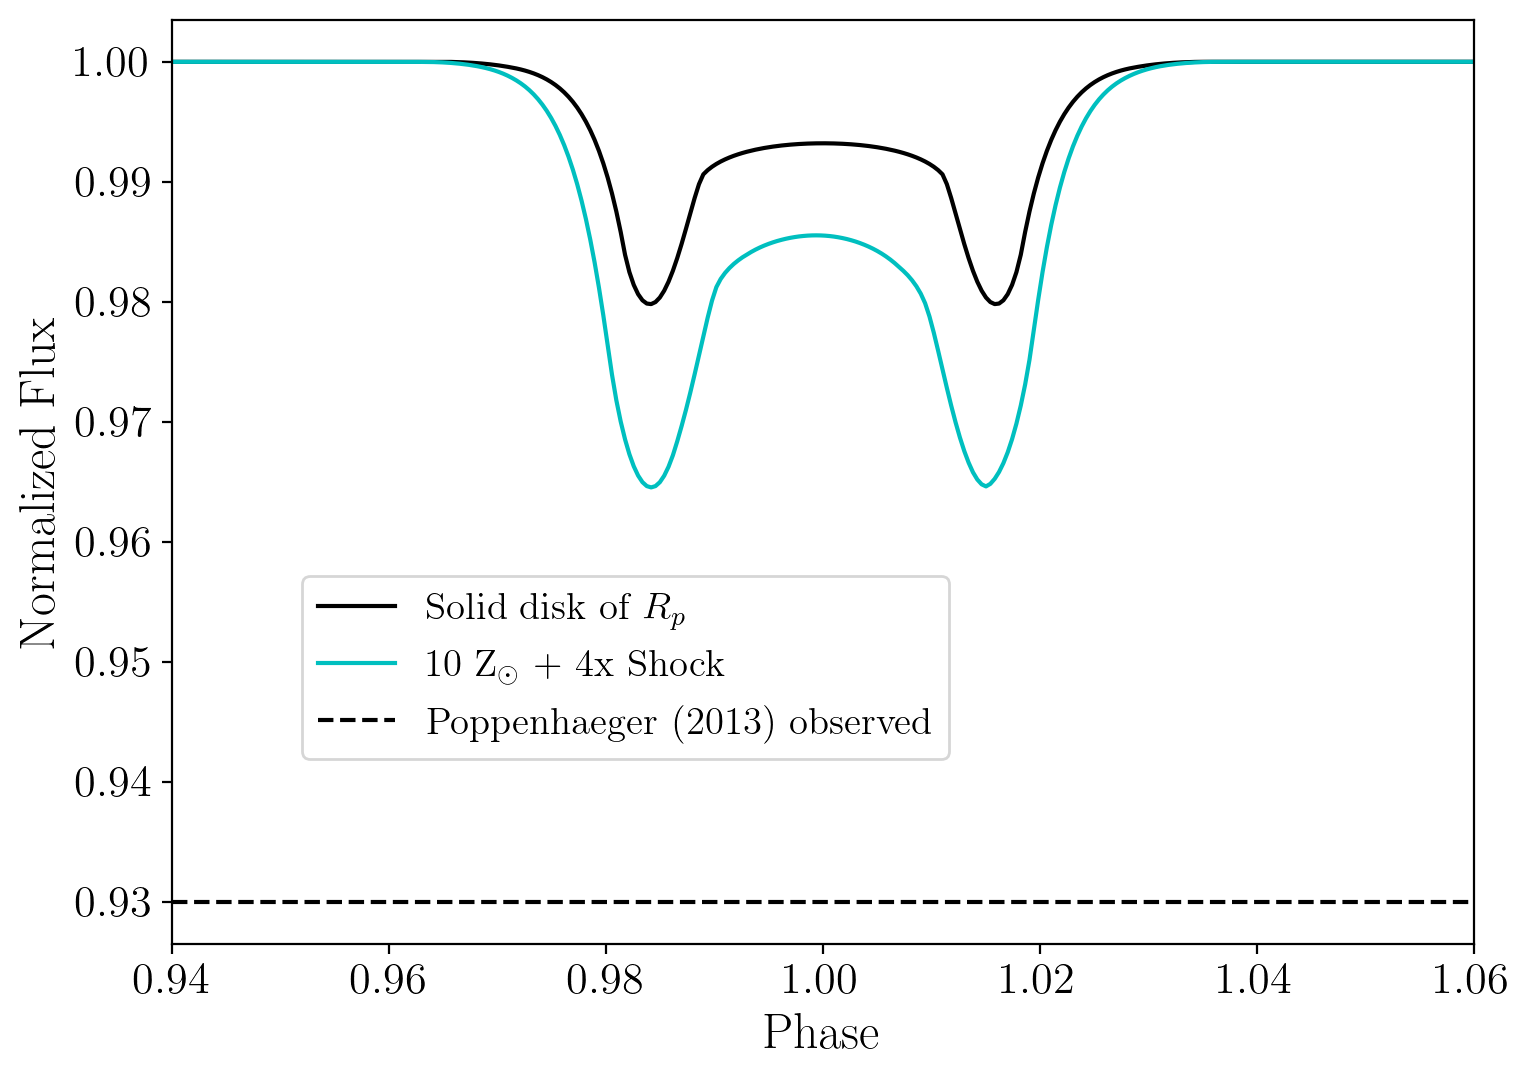

In [17]:
import xt_fns as xf
import numpy as np
import matplotlib.pyplot as plt
import batman



#Stellar parameters
Rs = 0.805 #radius (Rsun)
Ms = 0.846 #mass (Msun)
T = 0.34 #kT of corona in keV

# x = np.linspace(0,Rmax,100)
# tau_array = np.ones_like(x)*10
# # tau_array[x>1] = 


#planetary parameters
Rp_surf = 8135789600.0
x,tau_array = np.load('../batmanX-rays-main/tau_profiles/tau_HD189_10Z.npy')
# profiles_array = np.load(f'../batman_xrays_atmo_escape/tau_profiles/tau_HD189_10Z_all.npy', allow_pickle=True)
# x = profiles_array[0]['rs']
# tau_array = profiles_array[0]['taus']
# x2,tau_array_bow = np.load('../batmanX-rays-main/tau_HD189_5Z_x4.npy')
x2,tau_array_bow = np.load('../batman_xrays_atmo_escape/tau_profiles/testing_10Z_shock_enh1_200eV.npy').T
# x2,tau_array_bow = np.load('../batmanX-rays-main/tau_profiles/tau_HD189_10Z.npy')
# x2,tau_array2 = np.load('../batmanX-rays-main/tau_HD189_1Z.npy')*4
# tau_array2 = np.zeros_like(tau_array2)

# x2,tau_array2 = np.load('../batmanX-rays-main/tau_HD189_1Z_shock.npy')
Rmax = max(x)/Rp_surf
print(Rmax)
Rp = Rp_surf*Rmax #planet radius in cm 
RpRs = Rp/(Rs*6.957e10) #Rmax/Rs
aRs = 8.2830 #a/Rs
# inc =  #inclination
inc = 85.580 #inclination
t0 = 1 #phase of transit centre


#get emission scale height in stellar radii
He = xf.HfromT(T, Rs, Ms)
#get emission scale height in batman coordinates
he = xf.hfromH(He)
Nscale = 6
#photosphere edge in batman coords
Rx = xf.calcRx(he, Nscale)
intVals = xf.get_intVals(he, Nscale)

#set up the object to store the transit parameters
params = batman.TransitParams()
params.t0 = t0               #time of inferior conjunction
params.per = 1               #orbital period - set to 1 to keep within phase definitions
params.rp = RpRs * Rx        #planet radius (in units of stellar radii)
params.a = aRs * Rx          #semi-major axis (in units of stellar radii)
params.inc = inc             #orbital inclination (in degrees)
params.ecc = 0.              #eccentricity
params.w = 90.               #longitude of periastron (in degrees)
params.limb_dark = "custom"  #limb darkening model
params.u = [0]*6             #limb darkening coefficients
params.u[0] = intVals
params.tau = tau_array
params.tau2 = tau_array_bow

#initialise a batman model at the calcuation phase times
#Setting up times for model
phaSt, phaFi = 0.9, 1.1 #phases to model
numBins = 500 #500 #number of bins to calculate the light curve at
binPhases = np.linspace(phaSt, phaFi, numBins) #bin centres

#set up batman model
mod = batman.TransitModel(params, binPhases, fac=5e-4)
#get the fluxes
flux1 = mod.light_curve(params)

pltparams = {"text.color" : "k",
          "xtick.color" : "k",
          "ytick.color" : "k"}
plt.rcParams.update(pltparams)


#plot the model
fig1 = plt.figure(figsize=(8.4,6.0))
# # plt.plot(binPhases, old_flux,c='k') #Plot model
old_bin, old_flux = np.load('tau_profiles/og_transit_hd189.npy').T
plt.plot(old_bin, old_flux,c='k',ls='-',label=r'Solid disk of $R_p$') #Plot model
# old_bin, old_flux = np.load('transit_hd189_1Z.npy').T
# plt.plot(old_bin, old_flux,c='k',ls='--',label=r'1 Z$_\odot$') #Plot model
# old_bin, old_flux = np.load('transit_hd189_1Z_bow.npy').T
# plt.plot(old_bin, old_flux,c='g',ls='-',label=r'1 Z$_\odot$ + Bow Shock') #Plot model
#data
plt.plot(binPhases, flux1,c='c',label=r'10 Z$_\odot$ + 4x Shock') #Plot model
# old_bin10, old_flux10 = 
# np.load('transit_hd189_10Z.npy').T
# plt.plot(old_bin10, old_flux10,c='b',ls='--',label=r'10 Z$_\odot$') #Plot model
plt.axhline(0.93,c='k',ls='--',label='Poppenhaeger (2013) observed')
plt.xlabel('Phase',fontsize=18)
plt.ylabel('Normalized Flux',fontsize=18)
plt.tick_params(labelsize=16)
plt.xlim(0.94,1.06)
plt.legend(fontsize=14,loc=[0.1,0.2])
# plt.axvline(1.0,c='yellow',ls='--')

#plt.savefig('optR_HeBourrier.pdf', dpi=300)

In [ ]:
np.save('../copy/transit_profiles/testing_10Z_shock_enh1_200eV.npy', np.column_stack([binPhases, flux1]))

In [31]:
profiles_array = np.load(f'../batman_xrays_atmo_escape/tau_profiles/tau_HD189_10Z_all.npy', allow_pickle=True).T
for i,profile in enumerate(profiles_array):
    if profile['E']<=201:
        print(profile['E'], i)
        break

200.94963421775253 1254


In [ ]:
profiles_array = np.load(f'../batman_xrays_atmo_escape/tau_profiles/tau_HD189_10Z_all.npy', allow_pickle=True).T
x = profiles_array[-1]['rs']
profiles_array = np.load(f'../batman_xrays_atmo_escape/tau_profiles/tau_HD189_10Z_shock_enh1.npy', allow_pickle=True).T
x2 = profiles_array[-1]['rs']
print(x2) 
print(x) 
# tau_array = profiles_array[-1]['taus']
# plt.plot(x,tau_array,label='new')
# x_1,tau_array_1 = np.load('../batmanX-rays-main/tau_profiles/tau_HD189_10Z.npy')
# plt.plot(x_1,tau_array_1    ,label='old',ls='--')
# plt.legend()    
# # plt.yscale('log')
# print(x_1-x)
# # print(tau_array_1-tau_array)


[0.         0.05212312 0.10424623 0.15636935 0.20849246 0.26061558
 0.31273869 0.36486181 0.41698492 0.46910804 0.52123115 0.57335427
 0.62547738 0.6776005  0.72972361 0.78184673 0.83396984 0.88609296
 0.93821608 0.99033919 1.04246231 1.09458542 1.14670854 1.19883165
 1.25095477 1.30307788 1.355201   1.40732411 1.45944723 1.51157034
 1.56369346 1.61581657 1.66793969 1.7200628  1.77218592 1.82430904
 1.87643215 1.92855527 1.98067838 2.0328015  2.08492461 2.13704773
 2.18917084 2.24129396 2.29341707 2.34554019 2.3976633  2.44978642
 2.50190953 2.55403265 2.60615576 2.65827888 2.710402   2.76252511
 2.81464823 2.86677134 2.91889446 2.97101757 3.02314069 3.0752638
 3.12738692 3.17951003 3.23163315 3.28375626 3.33587938 3.38800249
 3.44012561 3.49224872 3.54437184 3.59649496 3.64861807 3.70074119
 3.7528643  3.80498742 3.85711053 3.90923365 3.96135676 4.01347988
 4.06560299 4.11772611 4.16984922 4.22197234 4.27409545 4.32621857
 4.37834168 4.4304648  4.48258792 4.53471103 4.58683415 4.63895

In [ ]:
import xt_fns as xf
import numpy as np
import matplotlib.pyplot as plt
import batman
import glob


#Stellar parameters
Rs = 0.805 #radius (Rsun)
Ms = 0.846 #mass (Msun)
T = 0.34 #kT of corona in keV

#planetary parameters
Rp_surf = 8135789600.0

for Z in [1,5,10]:
    # file_pattern = '../batmanX-rays-main/tau_profiles/tau_HD189_*eV_'+str(Z)+'Z.npy'
    # big_files = sorted(glob.glob(file_pattern))
    # big_files = big_files.append('../batmanX-rays-main/tau_profiles/tau_HD189_*eV_'+str(Z)+'Z_x4.npy')
    profiles_array = np.load(f'../batmanX-rays-main/tau_profiles/tau_HD189_{Z}Z_all.npy', allow_pickle=True)
    profiles_array_shock = np.load(f'../batmanX-rays-main/tau_profiles/tau_HD189_{Z}Z_shock.npy', allow_pickle=True)

    out = []
    for profile,profile_shock in zip(profiles_array, profiles_array_shock):
        E = profile['E']
        print(f'\rCalculating transit for {E} eV, {Z} Zsun', end='')
        x = profile['rs']
        tau_array = profile['taus']
        x2 = profile_shock['rs']
        tau_array_bow = profile_shock['taus']

        wavelength = E
        # x2 = x
        # tau_array_bow = tau_array

        Rmax = max(x)/Rp_surf
        Rp = Rp_surf*Rmax #planet radius in cm 
        RpRs = Rp/(Rs*6.957e10) #Rmax/Rs
        aRs = 8.2830 #a/Rs
        # inc =  #inclination
        inc = 85.580 #inclination
        t0 = 1 #phase of transit centre


        #get emission scale height in stellar radii
        He = xf.HfromT(T, Rs, Ms)
        #get emission scale height in batman coordinates
        he = xf.hfromH(He)
        Nscale = 6
        #photosphere edge in batman coords
        Rx = xf.calcRx(he, Nscale)
        intVals = xf.get_intVals(he, Nscale)

        #set up the object to store the transit parameters
        params = batman.TransitParams()
        params.t0 = t0               #time of inferior conjunction
        params.per = 1               #orbital period - set to 1 to keep within phase definitions
        params.rp = RpRs * Rx        #planet radius (in units of stellar radii)
        params.a = aRs * Rx          #semi-major axis (in units of stellar radii)
        params.inc = inc             #orbital inclination (in degrees)
        params.ecc = 0.              #eccentricity
        params.w = 90.               #longitude of periastron (in degrees)
        params.limb_dark = "custom"  #limb darkening model
        params.u = [0]*6             #limb darkening coefficients
        params.u[0] = intVals
        params.tau = tau_array
        params.tau2 = tau_array_bow

        #initialise a batman model at the calcuation phase times
        #Setting up times for model
        phaSt, phaFi = 0.9, 1.1 #phases to model
        numBins = 500 #500 #number of bins to calculate the light curve at
        binPhases = np.linspace(phaSt, phaFi, numBins) #bin centres

        #set up batman model
        mod = batman.TransitModel(params, binPhases, fac=5e-4)
        #get the fluxes
        flux1 = mod.light_curve(params)

        out.append({'E': E, 'binPhases': binPhases, 'transmission_frac': flux1})

        # result = np.column_stack((np.full_like(binPhases, wavelength), binPhases, flux1))
        # out.append(result)

        # out = np.append(out, np.column_stack((binPhases, flux1)),axis=1)
        # np.save(f'../copy/transit_profiles/HD189_{wavelength}_{Z}Z.npy', np.column_stack((binPhases, flux1)))
    np.save(f'../copy/transit_profiles/HD189_{Z}Z_shock.npy', np.vstack(out),allow_pickle=True)

    # np.savetxt(f'../copy/transit_profiles/HD189_{Z}Z_all.csv', np.vstack(out),delimiter= ',',header='energy,bin,Phase,flux')

Calculating transit for 1999.6020834059173 eV, 1 Zsun

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
#enahcned

#Stellar parameters
Rs = 0.805 #radius (Rsun)
Ms = 0.846 #mass (Msun)
T = 0.34 #kT of corona in keV

#planetary parameters
Rp_surf = 8135789600.0

for Z in [1,5,10]:
    # file_pattern = '../batmanX-rays-main/tau_profiles/tau_HD189_*eV_'+str(Z)+'Z.npy'
    # big_files = sorted(glob.glob(file_pattern))
    # big_files = big_files.append('../batmanX-rays-main/tau_profiles/tau_HD189_*eV_'+str(Z)+'Z_x4.npy')
    profiles_array = np.load(f'../batmanX-rays-main/tau_profiles/tau_HD189_{Z}Z_all.npy', allow_pickle=True)
    profiles_array_shock = np.load(f'../batmanX-rays-main/tau_profiles/tau_HD189_{Z}Z_x4.npy', allow_pickle=True)

    out = []
    for profile,profile_shock in zip(profiles_array, profiles_array_shock):
        E = profile['E']
        print(f'\rCalculating transit for {E} eV, {Z} Zsun', end='')
        x = profile['rs']
        tau_array = profile['taus']
        x2 = profile_shock['rs']
        tau_array_bow = profile_shock['taus']

        wavelength = E
        # x2 = x
        # tau_array_bow = tau_array

        Rmax = max(x)/Rp_surf
        Rp = Rp_surf*Rmax #planet radius in cm 
        RpRs = Rp/(Rs*6.957e10) #Rmax/Rs
        aRs = 8.2830 #a/Rs
        # inc =  #inclination
        inc = 85.580 #inclination
        t0 = 1 #phase of transit centre


        #get emission scale height in stellar radii
        He = xf.HfromT(T, Rs, Ms)
        #get emission scale height in batman coordinates
        he = xf.hfromH(He)
        Nscale = 6
        #photosphere edge in batman coords
        Rx = xf.calcRx(he, Nscale)
        intVals = xf.get_intVals(he, Nscale)

        #set up the object to store the transit parameters
        params = batman.TransitParams()
        params.t0 = t0               #time of inferior conjunction
        params.per = 1               #orbital period - set to 1 to keep within phase definitions
        params.rp = RpRs * Rx        #planet radius (in units of stellar radii)
        params.a = aRs * Rx          #semi-major axis (in units of stellar radii)
        params.inc = inc             #orbital inclination (in degrees)
        params.ecc = 0.              #eccentricity
        params.w = 90.               #longitude of periastron (in degrees)
        params.limb_dark = "custom"  #limb darkening model
        params.u = [0]*6             #limb darkening coefficients
        params.u[0] = intVals
        params.tau = tau_array
        params.tau2 = tau_array_bow

        #initialise a batman model at the calcuation phase times
        #Setting up times for model
        phaSt, phaFi = 0.9, 1.1 #phases to model
        numBins = 500 #500 #number of bins to calculate the light curve at
        binPhases = np.linspace(phaSt, phaFi, numBins) #bin centres

        #set up batman model
        mod = batman.TransitModel(params, binPhases, fac=5e-4)
        #get the fluxes
        flux1 = mod.light_curve(params)

        out.append({'E': E, 'binPhases': binPhases, 'transmission_frac': flux1})

        # result = np.column_stack((np.full_like(binPhases, wavelength), binPhases, flux1))
        # out.append(result)

        # out = np.append(out, np.column_stack((binPhases, flux1)),axis=1)
        # np.save(f'../copy/transit_profiles/HD189_{wavelength}_{Z}Z.npy', np.column_stack((binPhases, flux1)))
    np.save(f'../copy/transit_profiles/HD189_{Z}Z_shock_x4.npy', np.vstack(out),allow_pickle=True)

    # np.savetxt(f'../copy/transit_profiles/HD189_{Z}Z_all.csv', np.vstack(out),delimiter= ',',header='energy,bin,Phase,flux')

Calculating transit for 305.7112235542977 eV, 5 Zsunn

In [21]:
RpRs/5.6

0.1452719696949406

In [19]:
# double overlapping_area(double d, double x, double r)
# {
#     if (d >= x + r) return 0.0;
#     if (d <= fabs(x - r)) return M_PI * fmin(x, r) * fmin(x, r);

#     double arg1 = (d*d + x*x - r*r)/(2.0*d*x);
#     double arg2 = (d*d + r*r - x*x)/(2.0*d*r);
#     double arg3 = (-d + x + r)*(d + x - r)*(d - x + r)*(d + x + r);

#     return x*x*acos(arg1) + r*r*acos(arg2) - 0.5*sqrt(arg3);
# }

def overlapping_area(d,x,r):
    # if d >= x + r:
    #     return 0.0
    # if (d <= abs(x - r)):
    #     return np.pi * min(x, r) * min(x, r)
    arg1 = (d*d + x*x - r*r)/(2.0*d*x)
    arg2 = (d*d + r*r - x*x)/(2.0*d*r)
    arg3 = (-d + x + r)*(d + x - r)*(d - x + r)*(d + x + r)
    print(arg1,arg2, arg3)
    return x*x*np.arccos(arg1) + r*r*np.arccos(arg2) - 0.5*np.sqrt(arg3)

d = 0.806*6.957e10
x = 0.805*6.957e10
dx = x/1000
r =  8135789600.0
# print(d,x,dx,r)

A1 = overlapping_area(d,x,r)
A2 = overlapping_area(d,x+dx,r)

stellar_annulus = 2*np.pi*(x+dx)*dx

frac_coverage = (A2-A1)/stellar_annulus

print(1-frac_coverage)

0.9894618898057638 0.0810916671937369 8.270051401606487e+41
0.9894716768138138 0.0742131297376681 8.278944528224788e+41
0.9537818815111279


10001 10001
Total intensity = 1.0001969845031946


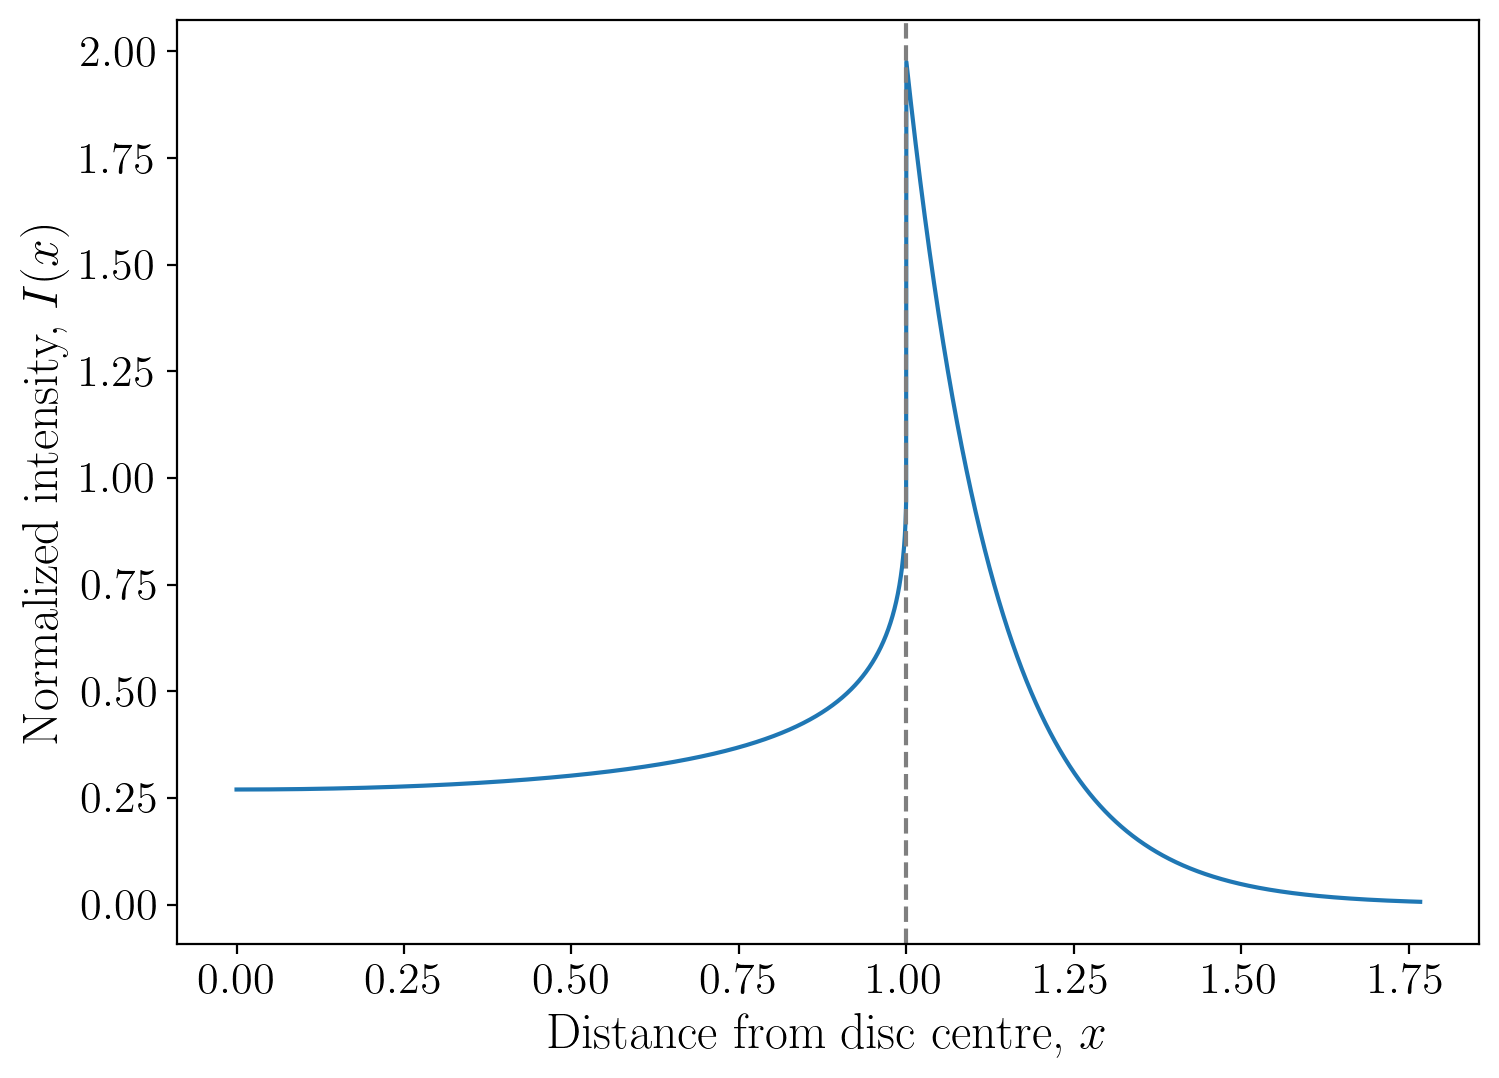

In [28]:
#get emission scale height in stellar radii
He = xf.HfromT(T, Rs, Ms)
#get emission scale height in batman coordinates
he = xf.hfromH(He)


#set up x   array for 10001 steps from x=0 to x=1
xs = np.linspace(0, 1, 10001)
#number of emission scale heights to calculate corona out to
Nscale = 6
#photosphere edge in batman coords
Rx = xf.calcRx(he, Nscale)
#integral values
intVals = xf.get_intVals(he, Nscale)

plt.rc('font', family='serif')

#plot1D intensity variation
fig1D = plt.figure(figsize=(8.4,6.0))

print(len(xs), len(intVals ))
plt.plot(xs/Rx,intVals)
plt.axvline(x=1, color='C7', ls='--')

plt.xlabel('Distance from disc centre, $x$',fontsize=18)
plt.ylabel('Normalized intensity, $I(x)$',fontsize=18)
plt.tick_params(labelsize=16)

import numpy as np

Itot = 2 * np.pi * np.trapz(intVals * xs, xs)
print("Total intensity =", Itot)

In [ ]:
def overlapping_area(d, x, r):
    """
    Area of overlap between two circles of radii x (star annulus inner edge)
    and r (planet), whose centres are separated by distance d.
    """
    if d >= x + r:
        return 0.0
    if d <= abs(x - r):
        return np.pi * min(x, r) ** 2
    arg1 = (d*d + x*x - r*r) / (2.0 * d * x)
    arg2 = (d*d + r*r - x*x) / (2.0 * d * r)
    arg3 = (-d + x + r) * (d + x - r) * (d - x + r) * (d + x + r)
    arg3 = max(arg3, 0.0)   # guard against tiny negatives from floating point
    return (x*x * np.arccos(np.clip(arg1, -1, 1))
            + r*r * np.arccos(np.clip(arg2, -1, 1))
            - 0.5 * np.sqrt(arg3))


def obscuration_fraction(Intensity, x_array, rp, d):

    x_arr = x_array
    I_arr = Intensity

    numerator   = 0.0   # intensity-weighted blocked area
    denominator = 0.0   # intensity-weighted total stellar area (= total flux)

    for i in range(len(x_arr) - 1):
        x1 = x_arr[i]
        x2 = x_arr[i + 1]
        I  = 0.5 * (I_arr[i] + I_arr[i + 1])   # average intensity over annulus

        # Change in planet-overlap area as the annulus outer edge moves from x1 to x2
        blocked_in_annulus = overlapping_area(d, x2, rp) - overlapping_area(d, x1, rp)

        full_annulus = np.pi * (x2**2 - x1**2)

        numerator   += I * blocked_in_annulus
        denominator += I * full_annulus

    frac_percent = 100.0 * numerator / denominator
    return frac_percent


RpRs = 0.145   # Rp/Rs
D  = 1     # d/Rs

data = np.loadtxt("normalized_intensity_profile_hd189.txt", comments='#')
x_array = data[:, 0]
Intensity = data[:, 1]

frac = obscuration_fraction(Intensity, x_array, RpRs, D)

print(f"Planet radius  (Rp/Rs) : {RpRs}")
print(f"Impact parameter (d/Rs): {D}")
print(f"Geometric (Rp/Rs)^2    : {100.0 * RpRs**2:.4f}%")
print(f"Obscuration fraction   : {frac:.4f}%")

Planet radius  (Rp/Rs) : 0.145
Impact parameter (d/Rs): 1
Geometric (Rp/Rs)^2    : 2.1025%
Obscuration fraction   : 2.0087%


In [29]:
np.savetxt('normalized_intensity_profile_hd189.txt', np.column_stack((xs/Rx, intVals)), header='x\tI(x)')

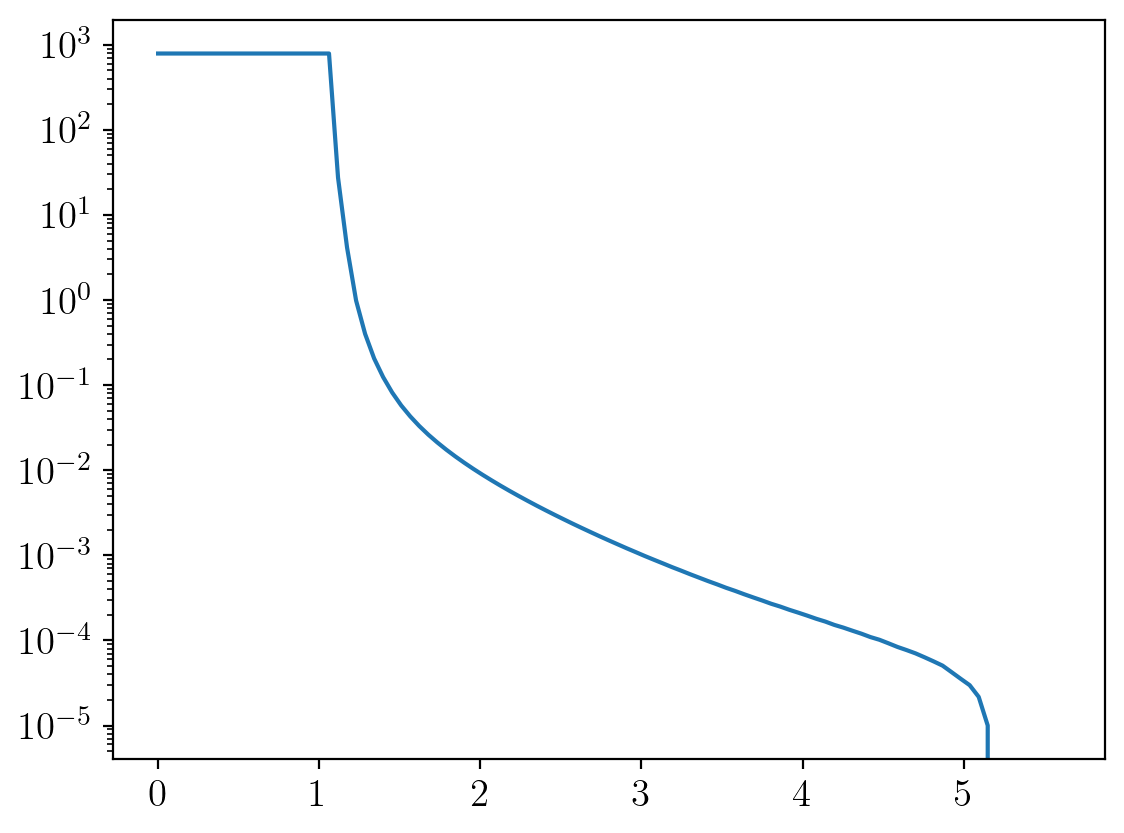

In [16]:
Rp_array, tau_array = np.load('../batmanX-rays-main/tau_HD189_10Z.npy')
plt.plot(Rp_array/Rp_surf, tau_array)
plt.yscale('log')
plt.show()

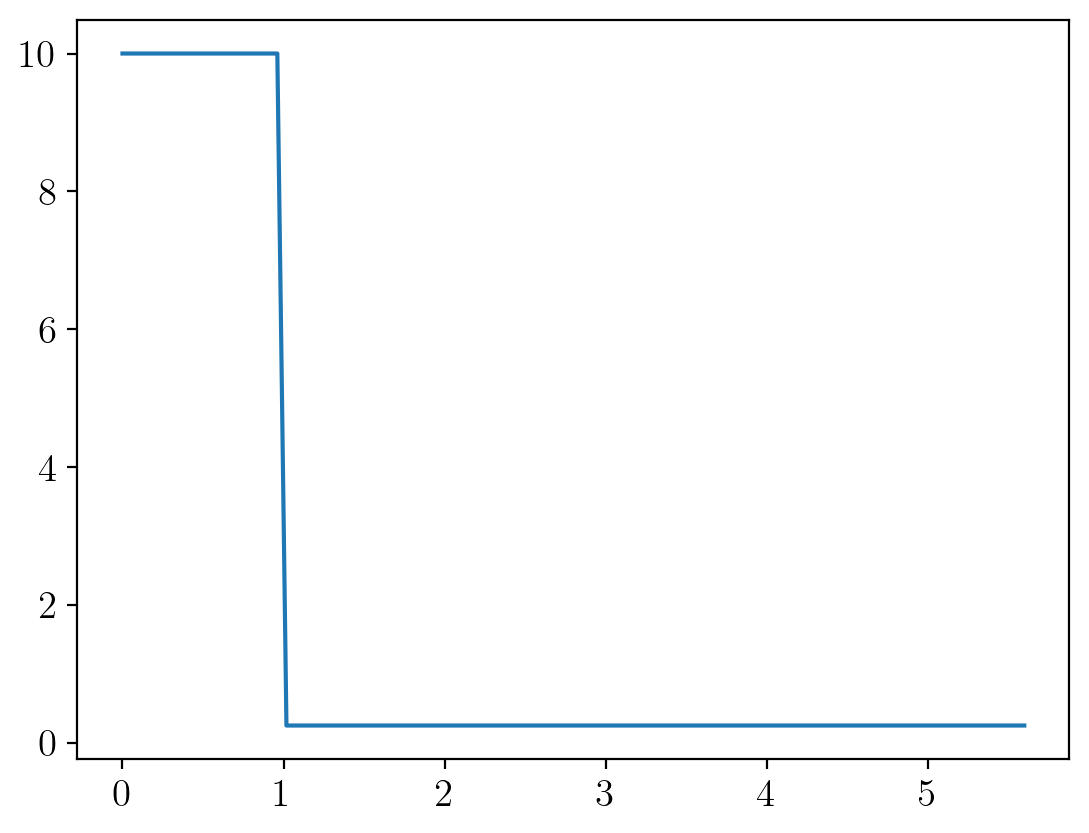

In [2]:
x = np.linspace(0,5.6,100)
tau_array = np.ones_like(x)*10
tau_array[x>1] = 0.25
plt.plot(x, tau_array)

Next try tau[11] = 100 for the whole array in tau.h

Then tau[11] = 1e-2

Then tau[11] = 1e-4

In [9]:
np.save('hd189_1Z_atmo.npy',np.column_stack((binPhases,flux1)))

In [ ]:
# x, d, R, r_n, arg, trasnmission = np.genfromtxt('test_new',unpack=True,delimiter=',')
# ir, r_n, trasnmission = np.genfromtxt('transmissions.txt',unpack=True,delimiter=',')
# x, d, R, arg1, arg2, arg3 = np.genfromtxt('x_test',unpack=True,delimiter=',')

In [6]:
with open('transmissions.txt', 'r') as f:
    for i, line in enumerate(f, 1):
    # for line in range(20):
        # Skip empty lines
        if not line.strip():
            continue
        parts = line.strip().split(',')
        print(parts)
        if i>100:
            break

['0', '0.000000', '1.000000']
['1', '0.000804', '1.000000']
['2', '0.001608', '1.000000']
['3', '0.002412', '1.000000']
['4', '0.003216', '1.000000']
['5', '0.004020', '1.000000']
['6', '0.004824', '1.000000']
['7', '0.005628', '1.000000']
['8', '0.006432', '1.000000']
['9', '0.007236', '1.000000']
['10', '0.008040', '1.000000']
['11', '0.008844', '1.000000']
['12', '0.009649', '1.000000']
['13', '0.010453', '1.000000']
['14', '0.011257', '1.000000']
['15', '0.012061', '1.000000']
['16', '0.012865', '1.000000']
['17', '0.013669', '1.000000']
['18', '0.014473', '1.000000']
['19', '0.015277', '1.000000']
['20', '0.016081', '1.000000']
['21', '0.016885', '1.000000']
['22', '0.017689', '1.000000']
['23', '0.018493', '1.000000']
['24', '0.019297', '1.000000']
['25', '0.020101', '1.000000']
['26', '0.020905', '1.000000']
['27', '0.021709', '1.000000']
['28', '0.022513', '1.000000']
['29', '0.023317', '1.000000']
['30', '0.024121', '1.000000']
['31', '0.024925', '1.000000']
['32', '0.025729',

In [ ]:
for i in range(len(x)):
    if (x[i]+d[i]) < R[i]:
        print(i)
        

In [5]:
lawofcos = (d**2 + r_n**2 - x**2)/(2.*d*r_n)

print(d[0], r_n[0], x[0],  lawofcos[0], np.arccos(lawofcos[0]))

0.00109 0.004433 0.0876 -791.9047935935031 nan


/var/folders/1b/b30tn34j4p104kcg6lt_mnf00000gn/T/ipykernel_35007/928444693.py:3: RuntimeWarning: invalid value encountered in arccos
  print(d[0], r_n[0], x[0],  lawofcos[0], np.arccos(lawofcos[0]))


In [6]:
print(trasnmission[10000])

0.012121


0.095897
0.033609


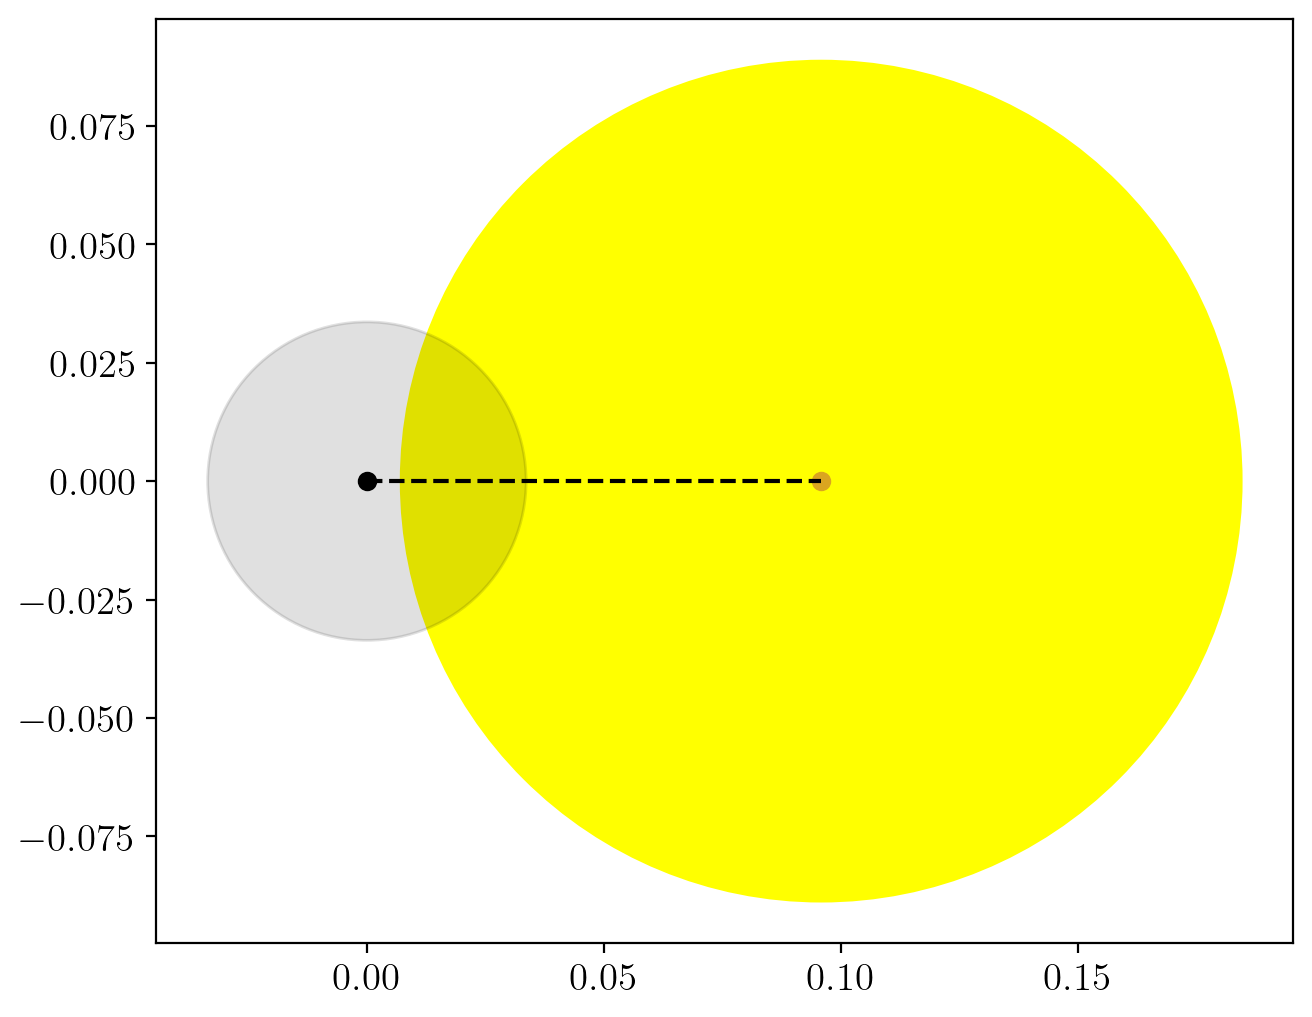

In [15]:
import matplotlib.patches as mpatches
fig2 = plt.figure(figsize=(8.4,6.0))
i = 9999
print(d[i])
print(r_n[i])
planet = mpatches.Circle((0,0),r_n[i], color='k', label='planet',alpha=trasnmission[i]*10)
star = mpatches.Circle((d[i],0),R[i], color='yellow', label='star')
plt.scatter(0,0,c='k')
plt.plot([0,d[i]],[0,0],c='k',ls='--')
plt.gca().add_patch(star)
plt.gca().add_patch(planet)
plt.scatter(d[i],0,c='goldenrod')

# plt.xlim(-r_n[i],d[i]+R[i]/8)
# plt.ylim(-R[i]/4,R[i]/4)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [12]:
np.arccos(lawofcos)

/var/folders/1b/b30tn34j4p104kcg6lt_mnf00000gn/T/ipykernel_9302/526751090.py:1: RuntimeWarning: invalid value encountered in arccos
  np.arccos(lawofcos)


array([nan, nan, nan, ..., nan, nan, nan])

In [ ]:
print(flux1)

In [ ]:
old_flux = flux1.copy()